<a href="https://colab.research.google.com/github/devdatta1429/BDA_Assignments/blob/main/PML/Day_16_03_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

from numpy import random
from collections import Counter

from numpy.linalg import inv
from numpy.linalg import eig

import matplotlib
from matplotlib import pyplot as plt

import seaborn as sns

import pylab
from pylab import legend
from pylab import plot, show, title, xlabel, ylabel

import scipy
from scipy import stats
from scipy.stats import binom,poisson,norm,t,expon,f
from sklearn.model_selection import train_test_split

import statsmodels
from statsmodels import stats
from statsmodels.stats import weightstats as ssw

import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from scipy.stats import chisquare
from scipy.stats import chi2_contingency

from statsmodels.stats import rates
from statsmodels.stats.rates import test_poisson
from statsmodels.stats.rates import test_poisson_2indep

from scipy.stats import chi2

from scipy.stats import f

In [1]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp

import sklearn
from sklearn.model_selection import train_test_split



import pandas as pd
import sklearn
from sklearn import linear_model
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel('/content/drive/MyDrive/CDAC/CDAC_DataBook.xlsx',sheet_name = 'faithful')

In [3]:
df.head()

,eruptions,waiting
0,3.600,79
1,1.800,54
2,3.333,74
3,2.283,62
4,4.533,85


In [5]:
scipy.stats.pearsonr(df.eruptions, df.waiting)

PearsonRResult(statistic=np.float64(0.9008111683218132), pvalue=np.float64(8.129958506615525e-100))

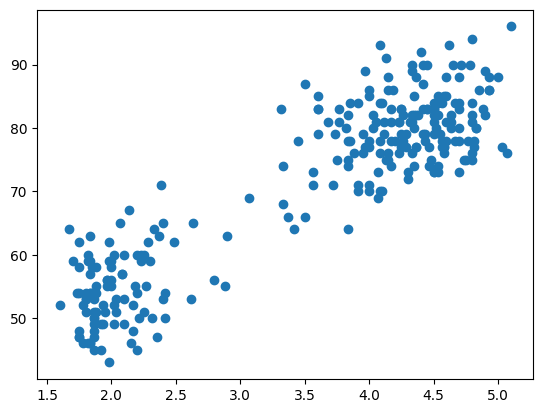

In [6]:
plt.scatter(df.eruptions, df.waiting)

#

In [8]:
x_train, x_test, y_train, y_test = train_test_split(df.waiting,df.eruptions, test_size=0.3)

In [20]:
x_train.head()

,waiting
182,83
248,67
50,75
209,83
200,60


In [21]:
y_train.head()

,eruptions
182,4.250
248,2.133
50,4.800
209,4.500
200,2.100


In [13]:
df.shape

(272, 2)

In [15]:
272*0.7

190.39999999999998

In [16]:
x_train.shape

(190,)

In [17]:
x_train, x_test, y_train, y_test = train_test_split(df.waiting,df.eruptions, test_size=0.3, random_state = 20)

In [19]:
x_train.head()

,waiting
182,83
248,67
50,75
209,83
200,60


In [22]:
x_train = sm.add_constant(x_train , prepend = False)
x_test = sm.add_constant(x_test , prepend = False)

In [25]:
x_train.head()

,waiting,const
182,83,1.0
248,67,1.0
50,75,1.0
209,83,1.0
200,60,1.0


In [67]:
# Prepare the model
mod1 = sm.OLS(y_train , x_train).fit()

In [32]:
print(mod1.summary())

                            OLS Regression Results                            
Dep. Variable:              eruptions   R-squared:                       0.804
Model:                            OLS   Adj. R-squared:                  0.803
Method:                 Least Squares   F-statistic:                     771.1
Date:                Wed, 03 Jun 2026   Prob (F-statistic):           1.94e-68
Time:                        06:05:55   Log-Likelihood:                -140.85
No. Observations:                 190   AIC:                             285.7
Df Residuals:                     188   BIC:                             292.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
waiting        0.0782      0.003     27.768      0.0

In [34]:
0.0782/0.003

26.066666666666666

In [35]:
-2.0814/0.203

-10.25320197044335

In [ ]:
#                                        0 -----> 0.025 {[0.025   (95% percent)   0.975]}  0.975 -----> 100

In [ ]:
# ==============================================================================
#                  coef    std err          t      P>|t|      [0.025      0.975]
# ------------------------------------------------------------------------------
# waiting        0.0782      0.003     27.768      0.000       0.073       0.084 the values is not fall berfore afer 0 . so it will get rejected
# const         -2.0814      0.203    -10.273      0.000      -2.481      -1.682           coef is 0.0782 . iy fall between  0.073    0.084
# ==============================================================================
# Omnibus:                        4.420   Durbin-Watson:                   1.870
# Prob(Omnibus):                  0.110   Jarque-Bera (JB):                2.690
# Skew:                          -0.041   Prob(JB):                        0.261
# Kurtosis:                       2.423   Cond. No.                         393.
# ==============================================================================

In [ ]:
# 1) Model for above data is

# eruptions=0.0782*waiting-2.0814

# 2) R-squared (Coefficient of detemination): 80% of variation in the model is expalined by predictor that is waiting

# 3) Decisions:
# from p value we conclude that waiting time influences eruptions
# also from the inreval we can say that as 0 does not fall in the interval we reject H0:m=0

In [ ]:
# eruptions = 0.0782 * waiting -2.08
# R-squared = coeffircint of determination

In [36]:
mydata = pd.DataFrame([[80,1],[90,1],[100,1]])

In [39]:
mypreds = mod1.predict(mydata)
mypreds

,0
0,4.176827
1,4.959109
2,5.741392


In [42]:
y_preds = mod1.predict(x_train)
y_preds.head()

,0
182,4.411512
248,3.159859
50,3.785686
209,4.411512
200,2.612262


In [44]:
y_train.head()

,eruptions
182,4.250
248,2.133
50,4.800
209,4.500
200,2.100


In [48]:
residuals = y_train - y_preds
residuals.head()

,0
182,-0.161512
248,-1.026859
50,1.014314
209,0.088488
200,-0.512262


In [ ]:
plt.hist(residuals)

In [65]:
#stands for sum square of error
SSE = sum(residuals**2)  #unexplained Variation
SSE

48.99679457123917

In [66]:
#stands for sum square of total variations
SST = sum((y_train - np.mean(y_train))**2)  #unexplained Variation
SST

249.95112065263157

In [68]:
# sum square of regression or explained variation
SSR = SST - SSE
SSR

200.9543260813924

In [69]:
#Fraction of total variation explained by the model.
# the ratio is the same as R2
SSR/SST

0.803974495320098

In [71]:
# NUmber of values = 190
# Totaol DoF = 189
# DoF for the Regression = 2-1 =1
# DoF for the error or residual = 189-1 = 188

In [81]:
F = (((SSR)/1))/(((SSE)/188))
F

771.0588750529828

In [82]:
p_value = 1 - f.cdf(F,1,188)
p_value

np.float64(1.1102230246251565e-16)